# Run 3 SIDM signal validation

Validates the privately-produced Run 3 signal LLPNanoAOD (`pp -> pscalar -> 2 dark photons -> lepton-jets`,
4Mu and 2Mu2E, four Run 3 eras, 2000 events/sample in 4 chunks) at **gen level**: measured/nominal proper
cτ, dark-photon mass, and lepton kinematics/collimation, read straight from `GenPart`. Samples are consumed
through the analysis location YAMLs (`sidm/configs/ntuples/signal_{4mu,2mu2e}_run3.yaml`) exactly as the
analysis would.

Proper cτ of a dark photon (pdgId 32) = |decay vertex - production vertex| / (p/m), the decay vertex being
its lepton daughter's production vertex — the same quantity the analysis lifetime study measures.

In [1]:
import sys, os
_root = os.getcwd().split("/sidm")[0]        # repo root, works from any clone
for _p in (_root, os.getcwd()):              # os.getcwd() = this study dir, where the helper lives
    if _p not in sys.path:
        sys.path.insert(1, _p)
import numpy as np, matplotlib.pyplot as plt, mplhep as hep
hep.style.use("CMS")
import run3_signal_validation as V
from sidm.tools import utilities

## 1. The analysis can find the samples via the Run 3 location YAML

In [2]:
fs = utilities.make_fileset(["4Mu_200GeV_1p2GeV_0p48mm"], "2022",
                            location_cfg="signal_4mu_run3.yaml", replace_xcache=True)
k = list(fs)[0]
print(k, "->", len(fs[k]["files"]), "chunk files; metadata:", fs[k]["metadata"])
print("first URL:", fs[k]["files"][0])

4Mu_200GeV_1p2GeV_0p48mm -> 4 chunk files; metadata: {'skim_factor': 1.0, 'is_data': False, 'year': '2022'}
first URL: root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/run3_samplegen/outputs/2022/SIDM_BsTo2DpTo4Mu_MBs-200_MDp-1p2_ctau-0p48/SIDM_BsTo2DpTo4Mu_MBs-200_MDp-1p2_ctau-0p48_2022_j000.root


## 2. Lifetime: measured/nominal proper cτ across a representative set (both channels)

Six points spanning mass and cτ, both channels. A correctly-set lifetime gives measured/nominal ≈ 1.

In [3]:
points = [("4Mu_100GeV_0p25GeV_2p0mm", "signal_4mu_run3.yaml"),
          ("4Mu_200GeV_1p2GeV_4p8mm",  "signal_4mu_run3.yaml"),
          ("4Mu_1000GeV_5p0GeV_4p0mm", "signal_4mu_run3.yaml"),
          ("2Mu2E_150GeV_0p25GeV_1p3mm","signal_2mu2e_run3.yaml"),
          ("2Mu2E_500GeV_5p0GeV_8p0mm","signal_2mu2e_run3.yaml"),
          ("2Mu2E_1000GeV_1p2GeV_0p96mm","signal_2mu2e_run3.yaml")]
res = [V.analyze(s, "2022", cfg) for s, cfg in points]
print(f"{'sample':32s}{'nom(mm)':>9s}{'meas(mm)':>10s}{'meas/nom':>10s}{'dpMass':>9s}{'nMu':>7s}{'nEl':>7s}")
for r in res:
    print(f"{r['sample']:32s}{r['nom']:9g}{r['meas']:10.3f}{r['meas']/r['nom']:10.3f}"
          f"{r['dpmass'].mean():9.3f}{r['nmu']:7d}{r['nel']:7d}")

sample                            nom(mm)  meas(mm)  meas/nom   dpMass    nMu    nEl
4Mu_100GeV_0p25GeV_2p0mm                2     1.980     0.990    0.257   8000      0
4Mu_200GeV_1p2GeV_4p8mm               4.8     4.920     1.025    1.200   8000      0
4Mu_1000GeV_5p0GeV_4p0mm                4     4.093     1.023    5.000   8000      0
2Mu2E_150GeV_0p25GeV_1p3mm            1.3     1.289     0.991    0.256   4000   4000
2Mu2E_500GeV_5p0GeV_8p0mm               8     7.875     0.984    5.000   4000   4000
2Mu2E_1000GeV_1p2GeV_0p96mm          0.96     0.936     0.974    1.201   4000   4000


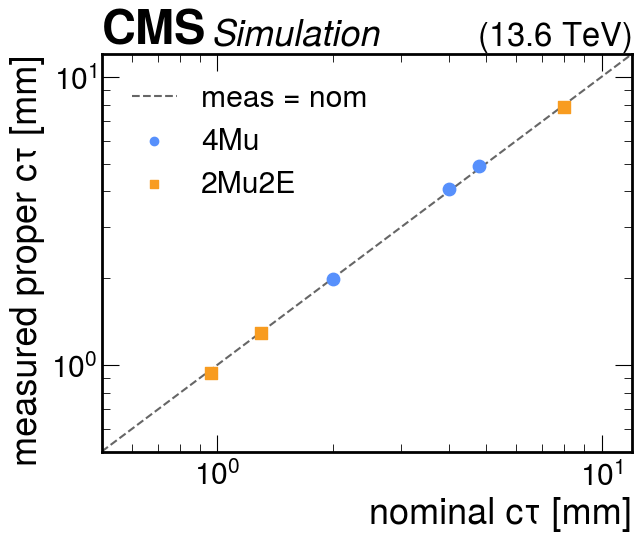

In [4]:
fig, ax = plt.subplots(figsize=(7,6))
for r in res:
    m = "o" if r["sample"].startswith("4Mu") else "s"
    c = "C0" if r["sample"].startswith("4Mu") else "C1"
    ax.scatter(r["nom"], r["meas"], marker=m, color=c, s=80, zorder=3)
lo, hi = 0.5, 12
ax.plot([lo,hi],[lo,hi], "k--", alpha=0.6, label="meas = nom")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
ax.set_xlabel("nominal cτ [mm]"); ax.set_ylabel("measured proper cτ [mm]")
ax.scatter([],[],marker="o",color="C0",label="4Mu"); ax.scatter([],[],marker="s",color="C1",label="2Mu2E")
ax.legend(); hep.cms.label("", data=False, com=13.6, ax=ax)
plt.tight_layout(); plt.show()

### Per-era: the same point validated in each of the four eras

In [5]:
for era in ["2022","2022EE","2023","2023BPix"]:
    r = V.analyze("4Mu_200GeV_1p2GeV_0p48mm", era, "signal_4mu_run3.yaml", nfiles=2)
    print(f"{era:9s} 4Mu_200GeV_1p2GeV_0p48mm: meas/nom={r['meas']/r['nom']:.3f}  "
          f"({len(r['proper_mm'])} dark photons in 2 chunks)")

2022      4Mu_200GeV_1p2GeV_0p48mm: meas/nom=1.015  (2000 dark photons in 2 chunks)


2022EE    4Mu_200GeV_1p2GeV_0p48mm: meas/nom=0.985  (2000 dark photons in 2 chunks)


2023      4Mu_200GeV_1p2GeV_0p48mm: meas/nom=0.972  (2000 dark photons in 2 chunks)


2023BPix  4Mu_200GeV_1p2GeV_0p48mm: meas/nom=1.000  (2000 dark photons in 2 chunks)


## 3. Kinematics for one point (4Mu, M_Bs=200, M_Zd=1.2, cτ=4.8 mm)

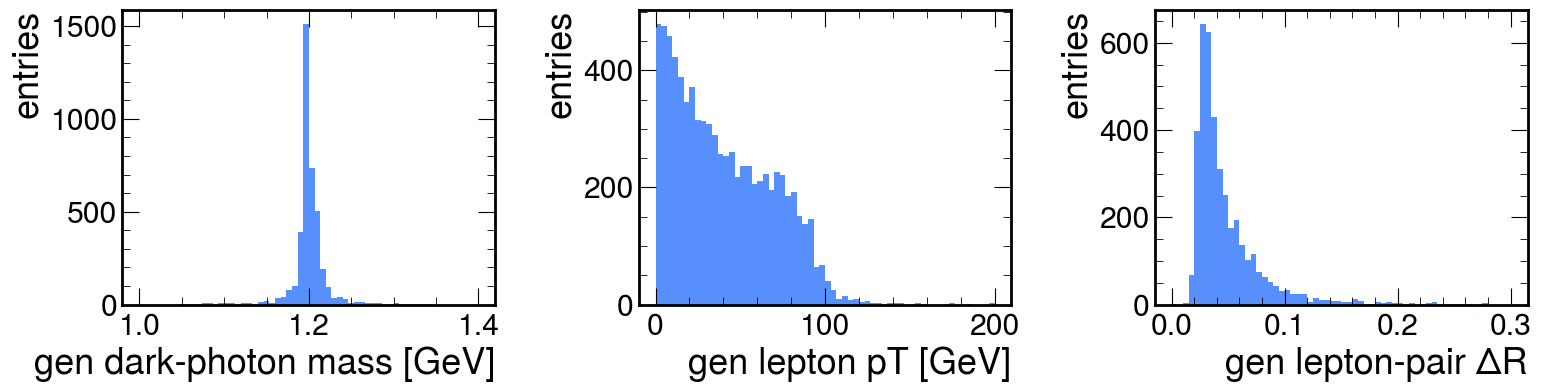

dark-photon mass mean=1.2000 GeV; median lepton pT=35.0 GeV; median ΔR(ll)=0.038  (collimated lepton pairs from a 1.2 GeV dark photon boosted by a 200 GeV pseudoscalar)


In [6]:
r = res[1]
fig, axs = plt.subplots(1, 3, figsize=(16,4.5))
axs[0].hist(r["dpmass"], bins=60, range=(1.0,1.4)); axs[0].set_xlabel("gen dark-photon mass [GeV]")
axs[1].hist(np.clip(r["lep_pt"], 0, 200), bins=60, range=(0,200)); axs[1].set_xlabel("gen lepton pT [GeV]")
axs[2].hist(r["dR"], bins=60, range=(0,0.3)); axs[2].set_xlabel("gen lepton-pair ΔR")
for a in axs: a.set_ylabel("entries")
plt.tight_layout(); plt.show()
print(f"dark-photon mass mean={r['dpmass'].mean():.4f} GeV; median lepton pT={np.median(r['lep_pt']):.1f} GeV; "
      f"median ΔR(ll)={np.median(r['dR']):.3f}  (collimated lepton pairs from a 1.2 GeV dark photon boosted by a 200 GeV pseudoscalar)")

## 4. Full grid: measured/nominal proper cτ over all 180 points (both channels)

Loads the full GEN-level scan (`run3_samplegen/validation/` on EOS): every point, every cτ.

180 points scanned; meas/nom mean=0.995 std=0.030 min=0.917 max=1.061; within 10% of 1.0: 180/180


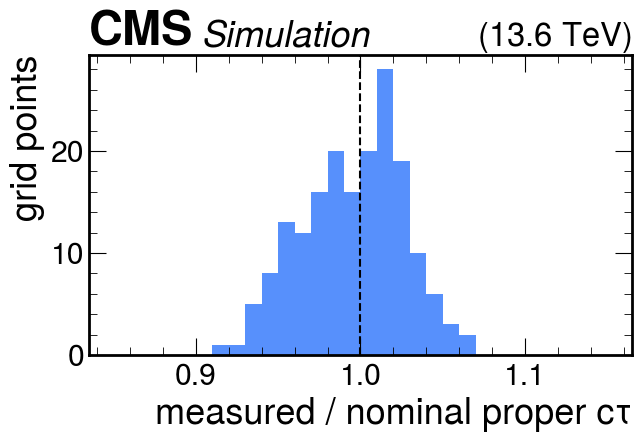

In [7]:
rows = V.load_grid_scan()
mn = np.array([x["meas_over_nom"] for x in rows if x["meas_over_nom"] > 0])
print(f"{len(rows)} points scanned; meas/nom mean={mn.mean():.3f} std={mn.std():.3f} "
      f"min={mn.min():.3f} max={mn.max():.3f}; within 10% of 1.0: {int((abs(mn-1)<=0.1).sum())}/{len(mn)}")
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(mn, bins=30, range=(0.85,1.15))
ax.axvline(1.0, color="k", ls="--"); ax.set_xlabel("measured / nominal proper cτ"); ax.set_ylabel("grid points")
hep.cms.label("", data=False, com=13.6, ax=ax); plt.tight_layout(); plt.show()

## 5. Displaced content — the `DSAMuon` collection the search needs

The custom LLPNanoAOD tier exists to keep the displaced standalone muons the standard tiers slim
away. For one displaced point (4Mu, M_Bs=200, M_Zd=1.2, **cτ = 4.8 mm**) we open a produced nano and
confirm the `DSAMuon` table is populated (~4 per event) and genuinely displaced — broad, large
transverse impact parameters |dxy|.

500 events; DSAMuon/event: mean 4.07, max 8, >=2 in 96% of events
DSAMuon pT median 21.8 GeV; |dxy| median 37 mm, 90th pct 497 mm  (broad/large -- the displaced standalone-muon signature)


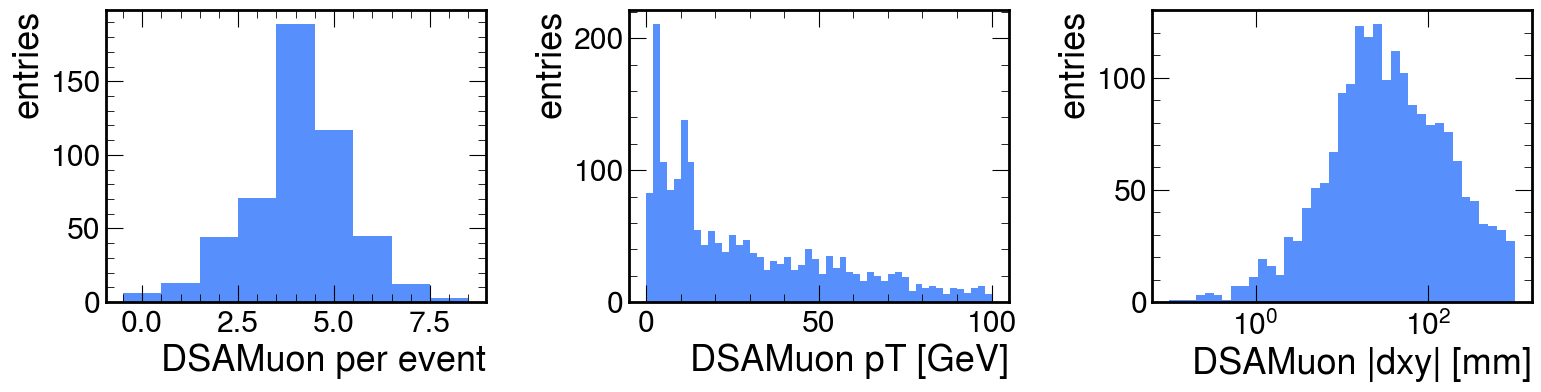

In [8]:
import uproot, awkward as ak
fs = utilities.make_fileset(["4Mu_200GeV_1p2GeV_4p8mm"], "2022", max_files=2,
                            location_cfg="signal_4mu_run3.yaml", replace_xcache=True)
ev = uproot.open(fs[list(fs)[0]]["files"][0])["Events"].arrays(["nDSAMuon", "DSAMuon_pt", "DSAMuon_dxy"])
ndsa = ak.to_numpy(ev["nDSAMuon"])
pt   = ak.to_numpy(ak.flatten(ev["DSAMuon_pt"]))
dxy  = ak.to_numpy(ak.flatten(abs(ev["DSAMuon_dxy"]))) * 10.0     # DSAMuon_dxy is in cm -> mm
print(f"{len(ndsa)} events; DSAMuon/event: mean {ndsa.mean():.2f}, max {int(ndsa.max())}, "
      f">=2 in {100*(ndsa>=2).mean():.0f}% of events")
print(f"DSAMuon pT median {np.median(pt):.1f} GeV; |dxy| median {np.median(dxy):.0f} mm, "
      f"90th pct {np.percentile(dxy,90):.0f} mm  (broad/large -- the displaced standalone-muon signature)")

fig, axs = plt.subplots(1, 3, figsize=(16,4.5))
axs[0].hist(ndsa, bins=range(0,10), align="left"); axs[0].set_xlabel("DSAMuon per event")
axs[1].hist(pt, bins=50, range=(0,100)); axs[1].set_xlabel("DSAMuon pT [GeV]")
axs[2].hist(dxy, bins=np.logspace(-1, 3, 40)); axs[2].set_xscale("log"); axs[2].set_xlabel("DSAMuon |dxy| [mm]")
for a in axs: a.set_ylabel("entries")
plt.tight_layout(); plt.show()

## 6. Note on running the full analysis

These samples are **gen-valid**. The coffea `SidmProcessor` does not yet run on Run 3 nano out of the box —
(1) it assumes Run 2 electron-ID branch names (`mvaFall17V2noIso_WPL`) and a `mass` field, and (2)
`sidm/configs/run_periods.yaml` has only `2018`, so `postprocess`'s lumi lookup raises `KeyError` for the
Run 3 eras. A Run 3 adaptation pass (electron ID + a Run 3 `run_periods` entry) is needed before the samples
can be processed with the full selection. Tracked separately.